

<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600&display=swap');

.project-header {
    text-align: center;
    background: #A7C7E7;
    font-family: 'Poppins', Arial, sans-serif;
    color: black;
    font-size: 26px;
    font-weight: bold;
    display: flex;
    justify-content: center;
    align-items: center;    
    height: 50px;          
    box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);
}
</style>

<div class="project-header"> TP1: Etude comparative des vectorisations/Word embedding/ dans le context analyse de sentiment</div>





#

<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600&display=swap');

.project-header {
    text-align: center;
    background: #A7C7E7;
    font-family: 'Poppins', Arial, sans-serif;
    color: black;
    font-size: 26px;
    font-weight: bold;
    display: flex;
    justify-content: center;
    align-items: center;    
    height: 50px;          
    box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);
}
</style>

<div class="project-header">Library and Installation</div>





In [1]:
!pip install numpy pandas matplotlib seaborn

In [2]:
!pip install wordcloud jinja2 scikit-learn nltk
 

In [1]:
import numpy as np        
import pandas as pd       
import matplotlib.pyplot as plt  
%matplotlib inline

# Importing WordCloud for text frequancy visualization 
from wordcloud import WordCloud

# Importing NLTK for natural language processing
import nltk
from nltk.corpus import stopwords    # For stopwords


# Downloading NLTK data
nltk.download('stopwords')   # Downloading stopwords data
nltk.download('punkt')       # Downloading tokenizer data


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sirou\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sirou\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [2]:
import os 
os.getcwd()
os.chdir('d:\\DIC3\\nlpCours\\TP')

In [3]:
df = pd.read_csv('../spam.csv', encoding='latin1')

In [4]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


#
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600&display=swap');

.project-header {
    text-align: center;
    background: #A7C7E7;
    font-family: 'Poppins', Arial, sans-serif;
    color: black;
    font-size: 26px;
    font-weight: bold;
    display: flex;
    justify-content: center;
    align-items: center;    
    height: 50px;          
    box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);
}
</style>

<div class="project-header">Data Cleaning</div>




In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
df.drop(columns = ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace = True)

In [7]:
df.head(5)

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
  # Rename the columns name
df.rename(columns = {'v1': 'target', 'v2': 'text'}, inplace = True)

In [9]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

In [10]:
df.head()


,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [11]:

df.isnull().sum()

target    0
text      0
dtype: int64

In [12]:

df.duplicated().sum()

403

In [13]:

df = df.drop_duplicates(keep = 'first')

In [14]:
df.shape

(5169, 2)

# 
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600&display=swap');

.project-header {
    text-align: center;
    background: #A7C7E7;
    font-family: 'Poppins', Arial, sans-serif;
    color: black;
    font-size: 26px;
    font-weight: bold;
    display: flex;
    justify-content: center;
    align-items: center;    
    height: 50px;          
    box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);
}
</style>

<div class="project-header"> 
Analyse Exploratoire

</div>




In [15]:
values = df['target'].value_counts()
total = values.sum()

percentage_0 = (values[0] /total) * 100
percentage_1 = (values[1]/ total) *100

print('percentage of 0 --> No Spam :' ,percentage_0)
print('percentage of 1--> Spam :' ,percentage_1)

percentage of 0 --> No Spam : 87.3669955503966
percentage of 1--> Spam : 12.633004449603405


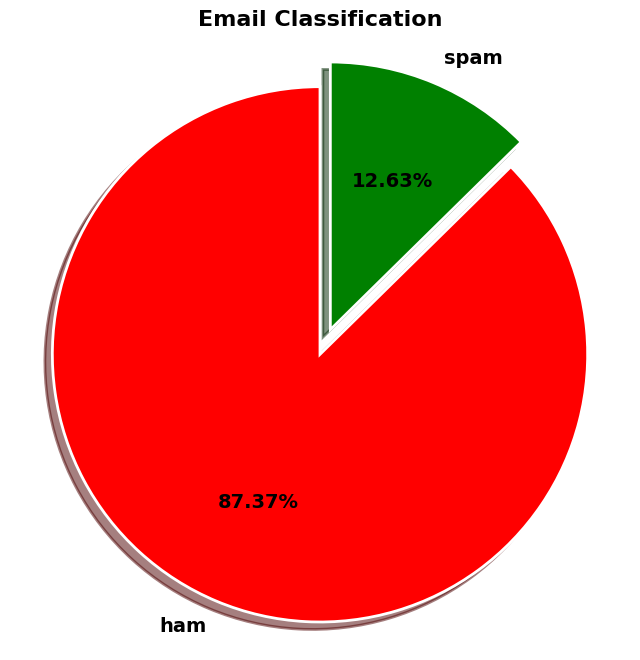

In [16]:
import matplotlib.pyplot as plt


# Define custom colors
colors = ['red', 'green']

# Define the explode parameter to create a gap between slices
explode = (0, 0.1)  # Explode the second slice (spam) by 10%

# Create a figure with a white background
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_facecolor('white')

# Create the pie chart with custom colors, labels, explode parameter, and shadow
wedges, texts, autotexts = ax.pie(
    values, labels=['ham', 'spam'],
    autopct='%0.2f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'},
    explode=explode,  # Apply the explode parameter
    shadow=True  # Add shadow
)

# Customize text properties
for text, autotext in zip(texts, autotexts):
    text.set(size=14, weight='bold')
    autotext.set(size=14, weight='bold')

ax.set_title('Email Classification', fontsize=16, fontweight='bold')

# Equal aspect ratio ensures that pie is drawn as a circle
ax.axis('equal')

plt.show()


In [17]:
df['num_characters'] = df['text'].apply(len)
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_sentence'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [18]:
df[['num_characters', 'num_words', 'num_sentence']].describe()

,num_characters,num_words,num_sentence
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [19]:
#ham
df[df['target'] == 0][['num_characters', 'num_words', 'num_sentence']].describe()

,num_characters,num_words,num_sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [20]:
#spam
df[df['target'] == 1][['num_characters', 'num_words', 'num_sentence']].describe()

,num_characters,num_words,num_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


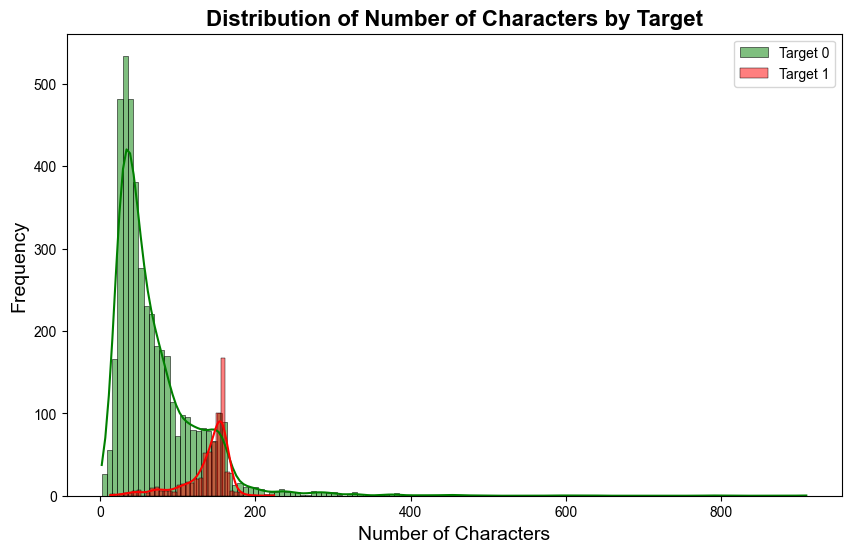

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot the histogram for target 0 in blue
sns.histplot(df[df['target'] == 0]['num_characters'], color='green', label='Target 0', kde=True)

# Plot the histogram for target 1 in red
sns.histplot(df[df['target'] == 1]['num_characters'], color='red', label='Target 1', kde=True)

# Add labels and a title
plt.xlabel('Number of Characters', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Distribution of Number of Characters by Target', fontsize=16, fontweight='bold')

# Add a legend
plt.legend()

# Customize the appearance of the plot
sns.set(style='whitegrid')  # Add a white grid background

# Show the plot
plt.show()


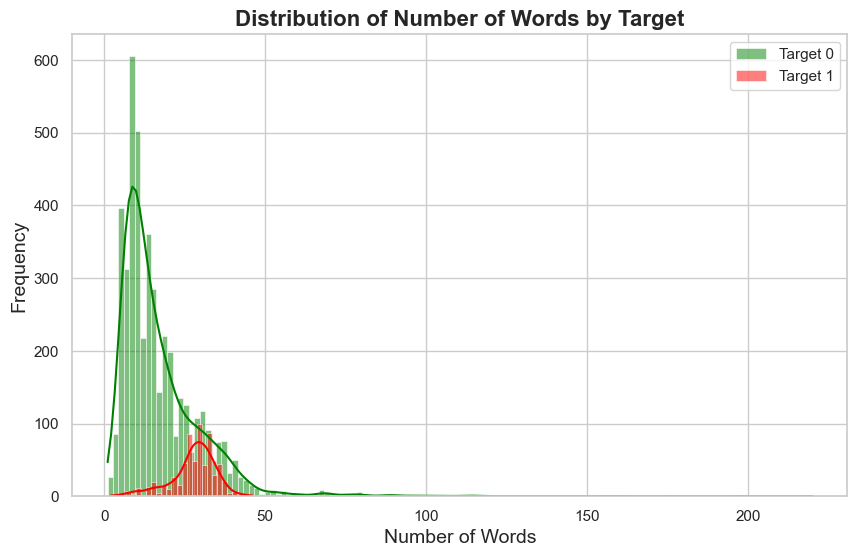

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure and set the figure size
plt.figure(figsize=(10, 6))

# Plot the histogram for target 0 in blue
sns.histplot(df[df['target'] == 0]['num_words'], color='green', label='Target 0', kde=True)

# Plot the histogram for target 1 in red
sns.histplot(df[df['target'] == 1]['num_words'], color='red', label='Target 1', kde=True)

# Add labels and a title
plt.xlabel('Number of Words', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Distribution of Number of Words by Target', fontsize=16, fontweight='bold')

# Add a legend
plt.legend()

# Customize the appearance of the plot
sns.set(style='whitegrid')  # Add a white grid background

# Show the plot
plt.show()


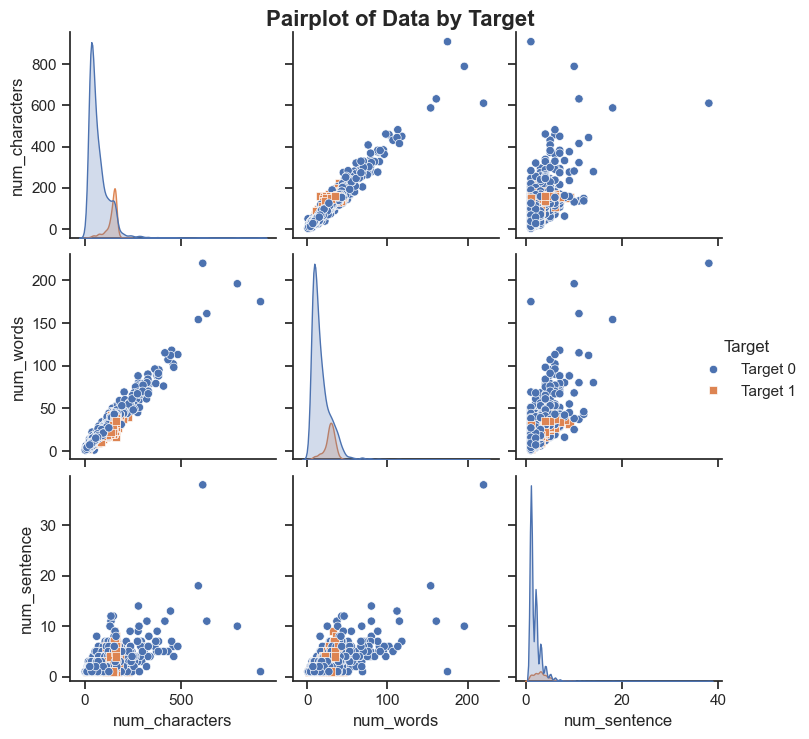

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a pairplot with custom styling
sns.set(style='ticks', color_codes=True)
g = sns.pairplot(df, hue='target', diag_kind='kde', markers=["o", "s"])

# Set a title for the pairplot
g.fig.suptitle("Pairplot of Data by Target", fontsize=16, fontweight='bold')
plt.subplots_adjust(top=0.95)  # Adjust the position of the title

# Customize the legend
g._legend.set_title('Target')
for t, l in zip(g._legend.texts, ["Target 0", "Target 1"]):
    t.set_text(l)

# Show the pairplot
plt.show()


In [24]:
df[['target','num_characters', 'num_words', 'num_sentence']].corr()

,target,num_characters,num_words,num_sentence
target,1.000000,0.384717,0.262912,0.263939
num_characters,0.384717,1.000000,0.965760,0.624139
num_words,0.262912,0.965760,1.000000,0.679971
num_sentence,0.263939,0.624139,0.679971,1.000000


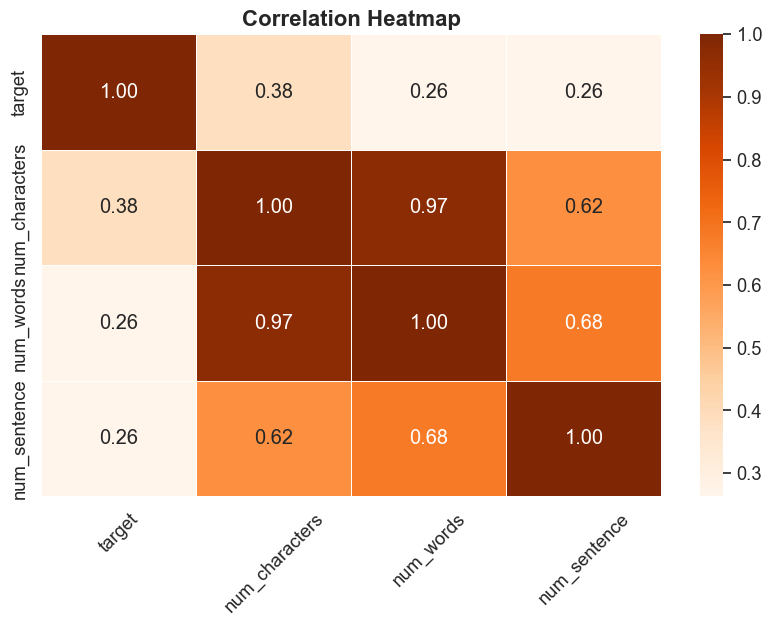

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the columns for the correlation matrix
correlation_matrix = df[['target', 'num_characters', 'num_words', 'num_sentence']].corr()

# Create a heatmap with custom styling
plt.figure(figsize=(10, 6))
sns.set(font_scale=1.2)  # Adjust font scale for better readability
sns.heatmap(correlation_matrix, annot=True, cmap='Oranges', linewidths=0.5, fmt=".2f")

# Set a title for the heatmap
plt.title("Correlation Heatmap", fontsize=16, fontweight='bold')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the heatmap
plt.show()


# 
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600&display=swap');

.project-header {
    text-align: center;
    background: #A7C7E7;
    font-family: 'Poppins', Arial, sans-serif;
    color: black;
    font-size: 26px;
    font-weight: bold;
    display: flex;
    justify-content: center;
    align-items: center;    
    height: 50px;          
    box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);
}
</style>

<div class="project-header"> Preprocessing</div>




In [26]:
import re
from nltk.stem.porter import PorterStemmer

import string

ps = PorterStemmer()

def transform_text(text):

    text = text.lower()
    text = re.sub(r"http\S+", "", text)  # Enlever les liens
    text = re.sub(r"@\w+", "", text)  # Enlever les mots commençant par "@"
    text = re.sub(r"\d+", "", text)  # Enlever les chiffres
    text = re.sub(r"[^\w\s]", "", text)  # Enlever les signes de ponctuation
    text = re.sub(r"\s+", " ", text).strip()  # Enlever les espaces multiples
    text = nltk.word_tokenize(text)
    
    # Removing special characters
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
            
    # Removing stop words and punctuation
    text = y[:]
    y.clear()
    
    # Loop through the tokens and remove stopwords and punctuation
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
        
    # Stemming using Porter Stemmer
    text = y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    
    # Join the processed tokens back into a single string
    return " ".join(y)


In [27]:
transform_text('Go until http/sites.colm @jurong 23425 point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...')

'go point crazi avail bugi n great world la e buffet cine got amor wat'

In [28]:
df['transformed_text'] = df['text'].apply(transform_text)

In [29]:
df.head(5)

,target,text,num_characters,num_words,num_sentence,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri wkli comp win fa cup final tkt st m...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah dont think goe usf live around though


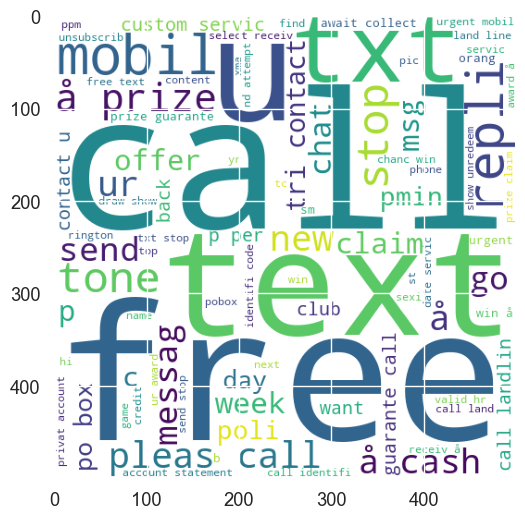

In [30]:
# Spam Word Count 

wc = WordCloud(width = 500, height = 500, min_font_size = 10, background_color = 'white')
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep = " "))
plt.figure(figsize = (15,6))
plt.imshow(spam_wc)
plt.show()

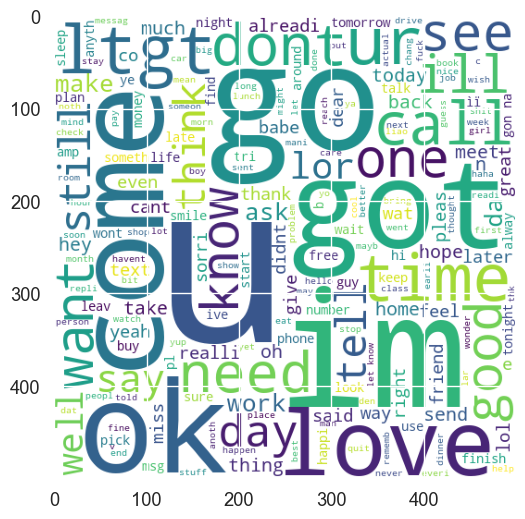

In [31]:
# Not Spam Word Count 
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep = " "))
plt.figure(figsize = (15,6))
plt.imshow(ham_wc)
plt.show()

In [32]:
spam_carpos = []
for sentence in df[df['target'] == 1]['transformed_text'].tolist():
    for word in sentence.split():
        spam_carpos.append(word)

In [33]:
from collections import Counter
filter_df = pd.DataFrame(Counter(spam_carpos).most_common(30))

C:\Users\sirou\AppData\Local\Temp\ipykernel_1876\2512895475.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = filter_df, x = filter_df[0], y = filter_df[1], palette = 'bright')


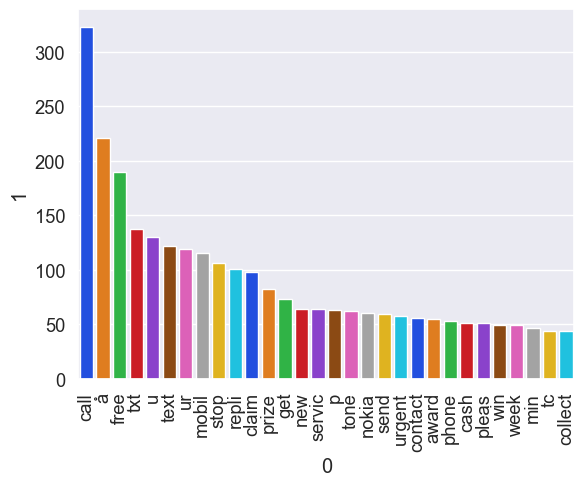

In [34]:
sns.barplot(data = filter_df, x = filter_df[0], y = filter_df[1], palette = 'bright')
plt.xticks(rotation = 90)
plt.show()

In [35]:
ham_carpos = []
for sentence in df[df['target'] == 0]['transformed_text'].tolist():
    for word in sentence.split():
        ham_carpos.append(word)

In [36]:
filter_ham_df = pd.DataFrame(Counter(spam_carpos).most_common(30))

C:\Users\sirou\AppData\Local\Temp\ipykernel_1876\699915630.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = filter_ham_df, x = filter_ham_df[0], y = filter_ham_df[1], palette = 'cool')


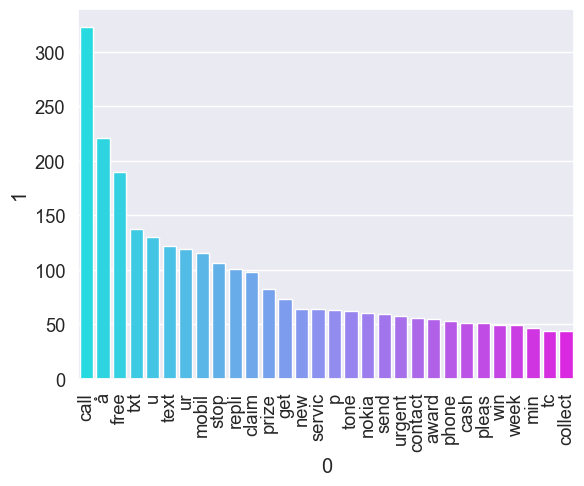

In [37]:
sns.barplot(data = filter_ham_df, x = filter_ham_df[0], y = filter_ham_df[1], palette = 'cool')
plt.xticks(rotation = 90)
plt.show()

In [38]:
df

,target,text,num_characters,num_words,num_sentence,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri wkli comp win fa cup final tkt st m...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah dont think goe usf live around though
...,...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4,nd time tri contact u u å pound prize claim ea...
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1,b go esplanad fr home
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2,piti mood soani suggest
5570,0,The guy did some bitching but I acted like i'd...,125,27,1,guy bitch act like id interest buy someth els ...


In [39]:
df.to_csv('spam_transformed.csv', index = False)

# 
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600&display=swap');

.project-header {
    text-align: center;
    background: #A7C7E7;
    font-family: 'Poppins', Arial, sans-serif;
    color: black;
    font-size: 26px;
    font-weight: bold;
    display: flex;
    justify-content: center;
    align-items: center;    
    height: 50px;          
    box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);
}
</style>

<div class="project-header"> Vectorization</div>




# 
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600&display=swap');

.project-header {
    text-align: center;
    background: #fdebd0 ;
    font-family: 'Poppins', Arial, sans-serif;
    color: black;
    font-size: 26px;
    font-weight: bold;
    display: flex;
    justify-content: center;
    align-items: center;    
    height: 50px;          
    box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);
}
</style>

<div class="project-header"> TF-IDF </div>




In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split

X = df['transformed_text']  
y = df['target']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


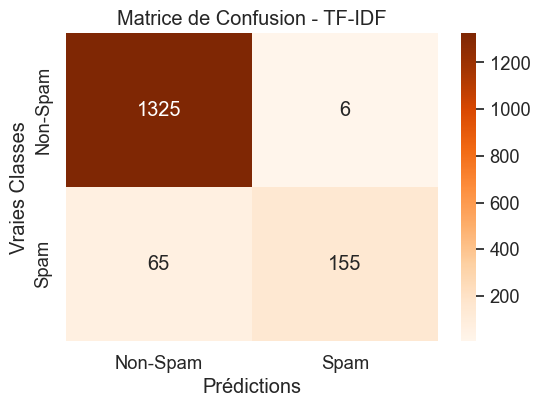

Rapport de Classification - TF-IDF
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1331
           1       0.96      0.70      0.81       220

    accuracy                           0.95      1551
   macro avg       0.96      0.85      0.89      1551
weighted avg       0.95      0.95      0.95      1551



In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# 2. Entraînement du modèle (Régression Logistique)
model_tfidf = LogisticRegression()
model_tfidf.fit(X_train_tfidf, y_train)

# 3. Prédictions et Matrice de Confusion
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)
conf_matrix_tfidf = confusion_matrix(y_test, y_pred_tfidf)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_tfidf, annot=True, fmt="d", cmap="Oranges", xticklabels=['Non-Spam', 'Spam'], yticklabels=['Non-Spam', 'Spam'])
plt.title("Matrice de Confusion - TF-IDF")
plt.xlabel("Prédictions")
plt.ylabel("Vraies Classes")
plt.show()

print("Rapport de Classification - TF-IDF")
print(classification_report(y_test, y_pred_tfidf))


# 
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600&display=swap');

.project-header {
    text-align: center;
    background: #fdebd0 ;
    font-family: 'Poppins', Arial, sans-serif;
    color: black;
    font-size: 26px;
    font-weight: bold;
    display: flex;
    justify-content: center;
    align-items: center;    
    height: 50px;          
    box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);
}
</style>

<div class="project-header"> N-gram </div>





************************* N-gram (N=1) **************************


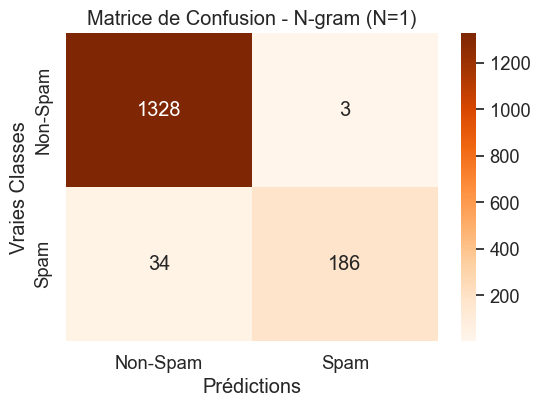

Rapport de Classification - N-gram (N=1)
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1331
           1       0.98      0.85      0.91       220

    accuracy                           0.98      1551
   macro avg       0.98      0.92      0.95      1551
weighted avg       0.98      0.98      0.98      1551


************************* N-gram (N=2) **************************


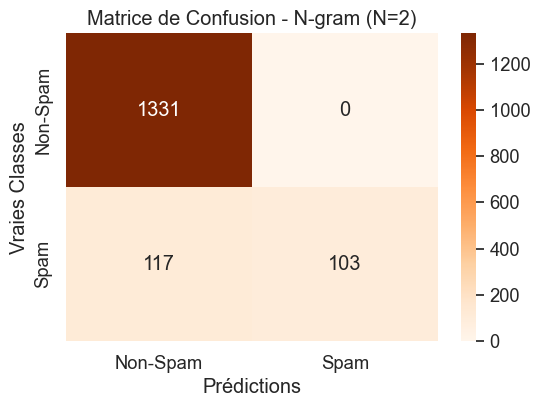

Rapport de Classification - N-gram (N=2)
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      1331
           1       1.00      0.47      0.64       220

    accuracy                           0.92      1551
   macro avg       0.96      0.73      0.80      1551
weighted avg       0.93      0.92      0.91      1551


************************* N-gram (N=3) **************************


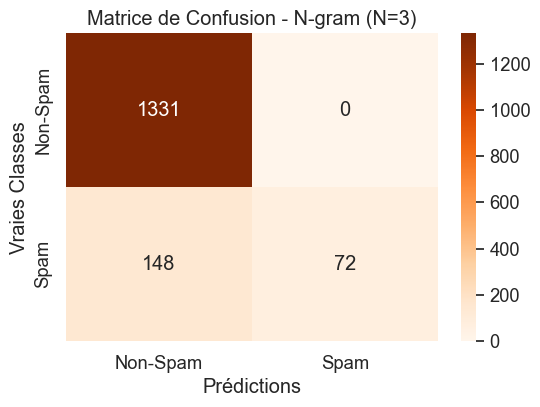

Rapport de Classification - N-gram (N=3)
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      1331
           1       1.00      0.33      0.49       220

    accuracy                           0.90      1551
   macro avg       0.95      0.66      0.72      1551
weighted avg       0.91      0.90      0.88      1551



In [42]:
from sklearn.feature_extraction.text import CountVectorizer

# Test sur trois valeurs de N (1-gram, 2-gram, 3-gram)
n_values = [1, 2, 3]

for n in n_values:
    print(f"\n************************* N-gram (N={n}) **************************")

    # 1. Vectorisation avec N-grams
    ngram_vectorizer = CountVectorizer(ngram_range=(n, n))
    X_train_ngram = ngram_vectorizer.fit_transform(X_train)
    X_test_ngram = ngram_vectorizer.transform(X_test)

    # 2. Entraînement du modèle
    model_ngram = LogisticRegression()
    model_ngram.fit(X_train_ngram, y_train)

    # 3. Prédictions et Matrice de Confusion
    y_pred_ngram = model_ngram.predict(X_test_ngram)
    conf_matrix_ngram = confusion_matrix(y_test, y_pred_ngram)

    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix_ngram, annot=True, fmt="d", cmap="Oranges", xticklabels=['Non-Spam', 'Spam'], yticklabels=['Non-Spam', 'Spam'])
    plt.title(f"Matrice de Confusion - N-gram (N={n})")
    plt.xlabel("Prédictions")
    plt.ylabel("Vraies Classes")
    plt.show()

    print(f"Rapport de Classification - N-gram (N={n})")
    print(classification_report(y_test, y_pred_ngram))


# 
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600&display=swap');

.project-header {
    text-align: center;
    background: #fdebd0 ;
    font-family: 'Poppins', Arial, sans-serif;
    color: black;
    font-size: 26px;
    font-weight: bold;
    display: flex;
    justify-content: center;
    align-items: center;    
    height: 50px;          
    box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);
}
</style>

<div class="project-header"> Bag of word </div>




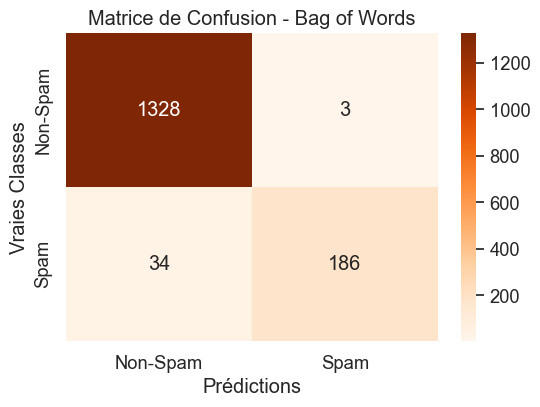

Rapport de Classification - Bag of Words
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1331
           1       0.98      0.85      0.91       220

    accuracy                           0.98      1551
   macro avg       0.98      0.92      0.95      1551
weighted avg       0.98      0.98      0.98      1551



In [43]:
# 1. Vectorisation avec Bag of Words
bow_vectorizer = CountVectorizer()
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

# 2. Entraînement du modèle
model_bow = LogisticRegression()
model_bow.fit(X_train_bow, y_train)

# 3. Prédictions et Matrice de Confusion
y_pred_bow = model_bow.predict(X_test_bow)
conf_matrix_bow = confusion_matrix(y_test, y_pred_bow)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_bow, annot=True, fmt="d", cmap="Oranges", xticklabels=['Non-Spam', 'Spam'], yticklabels=['Non-Spam', 'Spam'])
plt.title("Matrice de Confusion - Bag of Words")
plt.xlabel("Prédictions")
plt.ylabel("Vraies Classes")
plt.show()

print("Rapport de Classification - Bag of Words")
print(classification_report(y_test, y_pred_bow))


# 
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600&display=swap');

.project-header {
    text-align: center;
    background: #fdebd0 ;
    font-family: 'Poppins', Arial, sans-serif;
    color: black;
    font-size: 26px;
    font-weight: bold;
    display: flex;
    justify-content: center;
    align-items: center;    
    height: 50px;          
    box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);
}
</style>

<div class="project-header"> Word2Vec avec CBOW et Skip-gram </div>



In [44]:
from gensim.models import Word2Vec
#loading the downloaded  
# modelmodel = Word2Vec.load_word2vec_format('./GoogleNews-vectors-negative300/GoogleNews-vectors-negative300.bin', binary=True, norm_only=True)

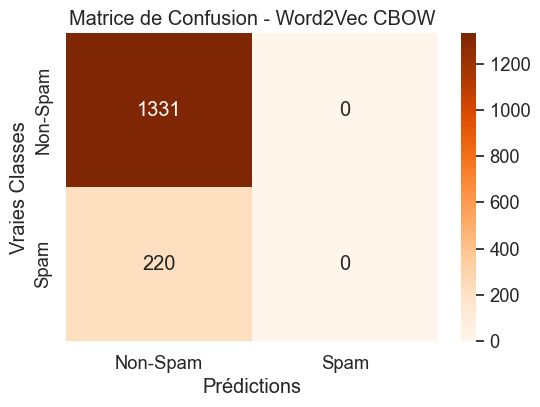

Rapport de Classification - Word2Vec CBOW
              precision    recall  f1-score   support

           0       0.86      1.00      0.92      1331
           1       0.00      0.00      0.00       220

    accuracy                           0.86      1551
   macro avg       0.43      0.50      0.46      1551
weighted avg       0.74      0.86      0.79      1551



c:\LogsInst\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\LogsInst\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\LogsInst\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


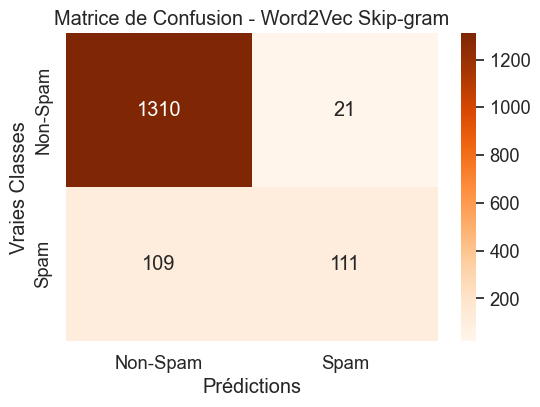

Rapport de Classification - Word2Vec Skip-gram
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      1331
           1       0.84      0.50      0.63       220

    accuracy                           0.92      1551
   macro avg       0.88      0.74      0.79      1551
weighted avg       0.91      0.92      0.91      1551



In [45]:
from gensim.models import Word2Vec
import numpy as np

# Transformer le texte en listes de mots pour entraîner Word2Vec
X_train_tokens = [text.split() for text in X_train]
X_test_tokens = [text.split() for text in X_test]

# Entraîner Word2Vec avec CBOW
word2vec_cbow = Word2Vec(sentences=X_train_tokens, vector_size=100, window=5, min_count=1, sg=0)

# Entraîner Word2Vec avec Skip-gram
word2vec_skipgram = Word2Vec(sentences=X_train_tokens, vector_size=100, window=5, min_count=1, sg=1)

# Fonction pour obtenir des vecteurs de phrase
def get_sentence_vector(model, tokens):
    # Retourne la moyenne des vecteurs des mots dans une phrase
    word_vectors = [model.wv[word] for word in tokens if word in model.wv]
    return np.mean(word_vectors, axis=0) if word_vectors else np.zeros(model.vector_size)

# Transformer les ensembles d'entraînement et de test pour CBOW
X_train_cbow = np.array([get_sentence_vector(word2vec_cbow, tokens) for tokens in X_train_tokens])
X_test_cbow = np.array([get_sentence_vector(word2vec_cbow, tokens) for tokens in X_test_tokens])

# Transformer les ensembles d'entraînement et de test pour Skip-gram
X_train_skipgram = np.array([get_sentence_vector(word2vec_skipgram, tokens) for tokens in X_train_tokens])
X_test_skipgram = np.array([get_sentence_vector(word2vec_skipgram, tokens) for tokens in X_test_tokens])

# Entraîner et évaluer le modèle pour CBOW
model_cbow = LogisticRegression()
model_cbow.fit(X_train_cbow, y_train)
y_pred_cbow = model_cbow.predict(X_test_cbow)
conf_matrix_cbow = confusion_matrix(y_test, y_pred_cbow)

#CBOW
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_cbow, annot=True, fmt="d", cmap="Oranges", xticklabels=['Non-Spam', 'Spam'], yticklabels=['Non-Spam', 'Spam'])
plt.title("Matrice de Confusion - Word2Vec CBOW")
plt.xlabel("Prédictions")
plt.ylabel("Vraies Classes")
plt.show()

print("Rapport de Classification - Word2Vec CBOW")
print(classification_report(y_test, y_pred_cbow))

# Entraîner et évaluer le modèle pour Skip-gram
model_skipgram = LogisticRegression()
model_skipgram.fit(X_train_skipgram, y_train)
y_pred_skipgram = model_skipgram.predict(X_test_skipgram)
conf_matrix_skipgram = confusion_matrix(y_test, y_pred_skipgram)

#Skip-gram
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_skipgram, annot=True, fmt="d", cmap="Oranges", xticklabels=['Non-Spam', 'Spam'], yticklabels=['Non-Spam', 'Spam'])
plt.title("Matrice de Confusion - Word2Vec Skip-gram")
plt.xlabel("Prédictions")
plt.ylabel("Vraies Classes")
plt.show()

print("Rapport de Classification - Word2Vec Skip-gram")
print(classification_report(y_test, y_pred_skipgram))


# 
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600&display=swap');

.project-header {
    text-align: center;
    background: #fdebd0 ;
    font-family: 'Poppins', Arial, sans-serif;
    color: black;
    font-size: 26px;
    font-weight: bold;
    display: flex;
    justify-content: center;
    align-items: center;    
    height: 50px;          
    box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);
}
</style>

<div class="project-header"> Glove </div>



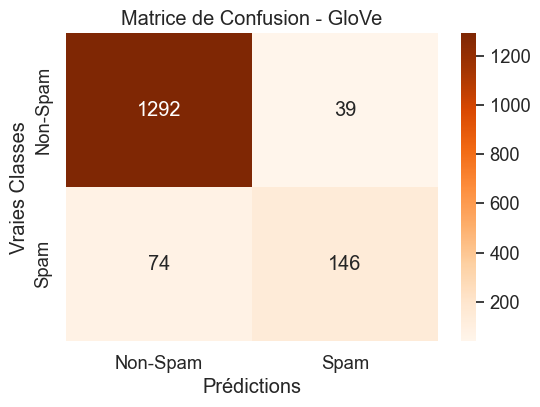

Rapport de Classification - GloVe
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1331
           1       0.79      0.66      0.72       220

    accuracy                           0.93      1551
   macro avg       0.87      0.82      0.84      1551
weighted avg       0.92      0.93      0.92      1551



In [46]:
import numpy as np

glove_path = './Glov/glove.6B.100d.txt'  
glove_embeddings = {}

# Charger les embeddings de GloVe
with open(glove_path, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.array(values[1:], dtype='float32')
        glove_embeddings[word] = vector

# Fonction pour obtenir des vecteurs de phrase en utilisant GloVe
def get_glove_sentence_vector(tokens, embeddings, vector_size=100):
    word_vectors = [embeddings[word] for word in tokens if word in embeddings]
    return np.mean(word_vectors, axis=0) if word_vectors else np.zeros(vector_size)

# Transformer les ensembles d'entraînement et de test
X_train_glove = np.array([get_glove_sentence_vector(text.split(), glove_embeddings) for text in X_train])
X_test_glove = np.array([get_glove_sentence_vector(text.split(), glove_embeddings) for text in X_test])

model_glove = LogisticRegression()
model_glove.fit(X_train_glove, y_train)
y_pred_glove = model_glove.predict(X_test_glove)

conf_matrix_glove = confusion_matrix(y_test, y_pred_glove)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_glove, annot=True, fmt="d", cmap="Oranges", xticklabels=['Non-Spam', 'Spam'], yticklabels=['Non-Spam', 'Spam'])
plt.title("Matrice de Confusion - GloVe")
plt.xlabel("Prédictions")
plt.ylabel("Vraies Classes")
plt.show()

print("Rapport de Classification - GloVe")
print(classification_report(y_test, y_pred_glove))


# 
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600&display=swap');

.project-header {
    text-align: center;
    background: #fdebd0 ;
    font-family: 'Poppins', Arial, sans-serif;
    color: black;
    font-size: 26px;
    font-weight: bold;
    display: flex;
    justify-content: center;
    align-items: center;    
    height: 50px;          
    box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);
}
</style>

<div class="project-header"> Fast Texte </div>



In [47]:
from gensim.models import FastText

Chargement du modèle FastText...
Modèle FastText chargé avec succès !
Transformation des phrases en vecteurs FastText...
Entraînement du modèle LogisticRegression...


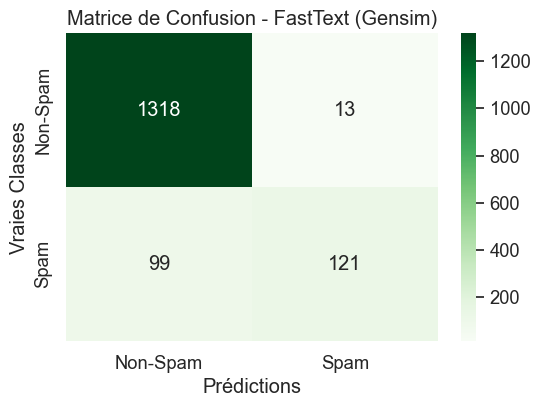

Rapport de Classification - FastText (Gensim)
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      1331
           1       0.90      0.55      0.68       220

    accuracy                           0.93      1551
   macro avg       0.92      0.77      0.82      1551
weighted avg       0.93      0.93      0.92      1551



In [48]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from gensim.models import fasttext
from gensim.models.keyedvectors import KeyedVectors

# Étape 1: Charger le modèle FastText avec Gensim
fasttext_path = './fastText/cc.en.300.bin'  # Chemin vers le fichier FastText binaire
print("Chargement du modèle FastText...")
ft_model = fasttext.load_facebook_model(fasttext_path)
print("Modèle FastText chargé avec succès !")

# Exemple pour vérifier si le modèle fonctionne
# print("Vecteur pour le mot 'hello':")
# print(ft_model.wv['hello'])

# Étape 2: Fonction pour obtenir un vecteur pour une phrase
def get_fasttext_sentence_vector_gensim(tokens, model, vector_size=300):
    word_vectors = [model.wv[word] for word in tokens if word in model.wv]
    return np.mean(word_vectors, axis=0) if word_vectors else np.zeros(vector_size)

# Étape 3: Préparer les données
# Assurez-vous que vos variables X2 et y2 sont prêtes
X2 = df['transformed_text']  
y2 = df['target'] 
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.3, random_state=42)

# Transformer les phrases en vecteurs
print("Transformation des phrases en vecteurs FastText...")
X_train_ft = np.array([get_fasttext_sentence_vector_gensim(text.split(), ft_model) for text in X2_train])
X_test_ft = np.array([get_fasttext_sentence_vector_gensim(text.split(), ft_model) for text in X2_test])

# Étape 4: Entraîner un modèle LogisticRegression
print("Entraînement du modèle LogisticRegression...")
model_ft = LogisticRegression(max_iter=1000)
model_ft.fit(X_train_ft, y2_train)

# Prédictions
y_pred_ft = model_ft.predict(X_test_ft)

# Étape 5: Évaluation
conf_matrix_ft = confusion_matrix(y2_test, y_pred_ft)

# Afficher la matrice de confusion
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_ft, annot=True, fmt="d", cmap="Greens", xticklabels=['Non-Spam', 'Spam'], yticklabels=['Non-Spam', 'Spam'])
plt.title("Matrice de Confusion - FastText (Gensim)")
plt.xlabel("Prédictions")
plt.ylabel("Vraies Classes")
plt.show()

# Rapport de classification
print("Rapport de Classification - FastText (Gensim)")
print(classification_report(y2_test, y_pred_ft))


# 
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600&display=swap');

.project-header {
    text-align: center;
    background: #fdebd0 ;
    font-family: 'Poppins', Arial, sans-serif;
    color: black;
    font-size: 26px;
    font-weight: bold;
    display: flex;
    justify-content: center;
    align-items: center;    
    height: 50px;          
    box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);
}
</style>

<div class="project-header"> All Confusion Matrix </div>



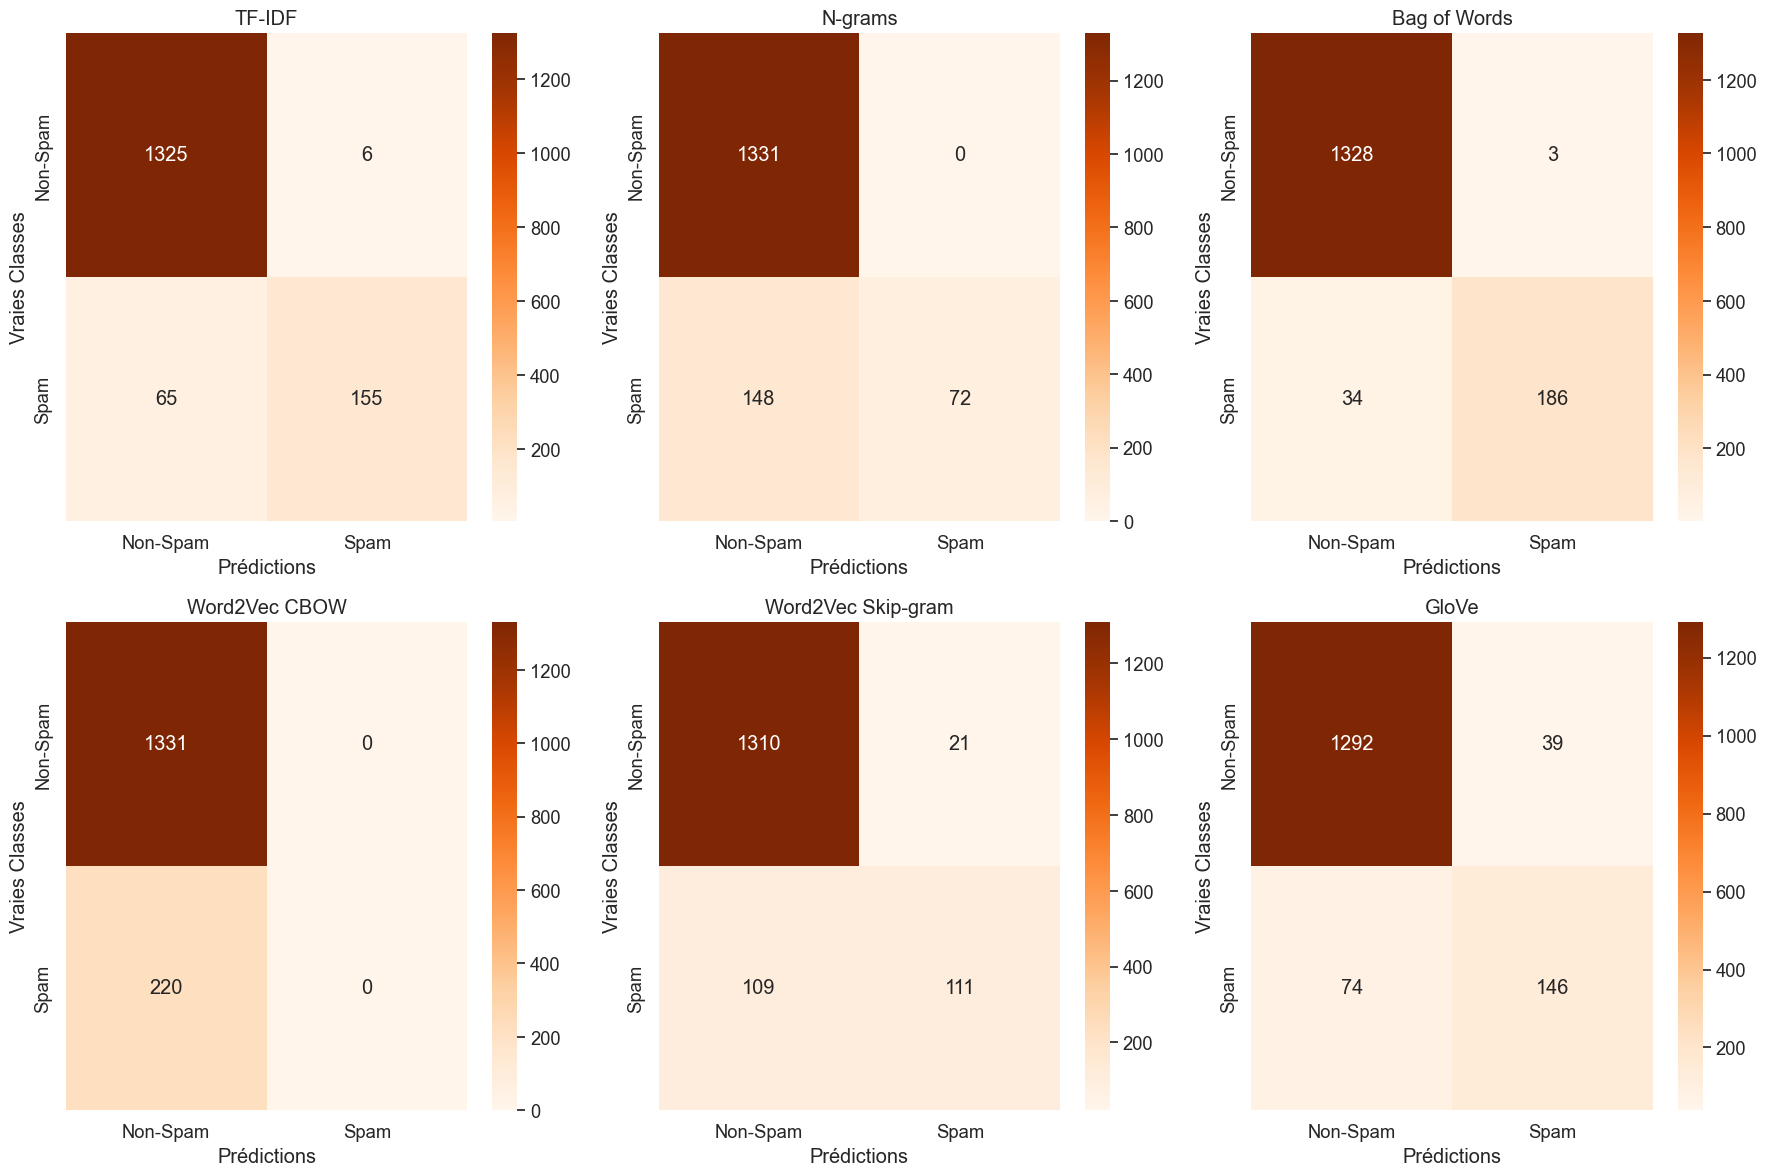

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Fonction pour afficher une matrice de confusion avec une étiquette spécifique
def plot_confusion_matrix(y_true, y_pred, title, ax):
    conf_matrix = confusion_matrix(y_true, y_pred)
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Oranges", xticklabels=['Non-Spam', 'Spam'], yticklabels=['Non-Spam', 'Spam'], ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Prédictions")
    ax.set_ylabel("Vraies Classes")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

plot_confusion_matrix(y_test, y_pred_tfidf, "TF-IDF", axes[0, 0])
plot_confusion_matrix(y_test, y_pred_ngram, "N-grams", axes[0, 1])
plot_confusion_matrix(y_test, y_pred_bow, "Bag of Words", axes[0, 2])
plot_confusion_matrix(y_test, y_pred_cbow, "Word2Vec CBOW", axes[1, 0])
plot_confusion_matrix(y_test, y_pred_skipgram, "Word2Vec Skip-gram", axes[1, 1])
plot_confusion_matrix(y_test, y_pred_glove, "GloVe", axes[1, 2])

plt.tight_layout()
plt.show()


# A faire
Améliorer la data processing Enlever tout ce qui est donnée non informationnelle: lien,chiffre, nom commençant par @, ..........

 Data Augmentation + Optimisation des hyper parametes qui impactent mieux les résultats Bag of Word(????) 
 and N-gram(jouer sur les valeurs de N)
Comparer les résultats avec les résultats en version optimisé. 
Et Faire aussi Fasttext

# Metrics pour dataset déséquilibré ou binaire 
1. Si le dataset est déséquilibré ou bien que la classification est binaire. On ne se limite plus à la  précision pour évaluer le modèle, on tient compte aussi les autres metrics comme R-call F-score et F-mesure

2. Si le dataset présente des classes minoritaire autrement dit déséquilibré. 

# Solutions ou dataset déséquilibré 
A chaque fois qu'on utilise data augamentation les calsses se conservent. 
1. Jouer sur la pondération des classes minoriataires(affeter des poids plus important pour la calsse minoritaire)
2. On équilibre les classes: 
    - OverSampling(En réduisant la classe majoritaire pour qu'il soit équilibré)
    - UnderSampling(On augmente la classe minoraitaire cette fois-ci)
        - Si on a des images: 
            - Approche classique
                - Faire des transformations géométriques(translation, transformation homothétique rotations) 
                - Jouer sur les contrastes(Augmenter/diminuer la luminosité, changer le fond, etc)
            - Approche basé sur le Deep Learning avec les réseaux générateurs appelés GANs(Generative Adversarial Network)
        - Si le dataset est de type textuelle
            - Approche classique
                - Replacement par synonyme
                - Back translation 
                - Insertion et suppression de mots pour une phrase donnée sauf si le mot est porteur de polarité
                - Mélanger l'ordre d'apparation des mots 
            - Approche basé sur le Deep Learning GPT and GAN 




Faire un équilibrage moi je vais utiliser SVC pour voir quel meilleur poid je dois affecter et Ousman fait le DataAugmentation pour son équilibrage



<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600&display=swap');

.project-header {
    text-align: center;
    background: #A7C7E7;
    font-family: 'Poppins', Arial, sans-serif;
    color: black;
    font-size: 26px;
    font-weight: bold;
    display: flex;
    justify-content: center;
    align-items: center;    
    height: 50px;          
    box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);
}
</style>

<div class="project-header">TP1 Version 2: Etude des variants d’algo ML en fonction d’un word embedding choisi ( voir meilleur algo)</div>





# 
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600&display=swap');

.project-header {
    text-align: center;
    background: #fdebd0 ;
    font-family: 'Poppins', Arial, sans-serif;
    color: black;
    font-size: 26px;
    font-weight: bold;
    display: flex;
    justify-content: center;
    align-items: center;    
    height: 50px;          
    box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);
}
</style>

<div class="project-header"> Choix: TF-IDF et Bag of word </div>



In [50]:
df.head()

,target,text,num_characters,num_words,num_sentence,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri wkli comp win fa cup final tkt st m...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah dont think goe usf live around though


In [51]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

X = df['transformed_text']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialiser CountVectorizer pour Bag of Words
bow_vectorizer = CountVectorizer(max_features=2000, ngram_range=(1, 2))
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

# Initialiser TfidfVectorizer pour TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=2000, ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)


In [52]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='linear'),
    "Decision Tree": DecisionTreeClassifier(),
    "k-NN": KNeighborsClassifier()
}

# Fonction pour entraîner et évaluer les modèles
def evaluate_models(X_train, X_test, y_train, y_test, vectorization_type):
    results = {}
    for name, model in models.items():
        print(f"\nModèle : {name} avec {vectorization_type}")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        print(classification_report(y_test, y_pred))
        conf_matrix = confusion_matrix(y_test, y_pred)
        print("Matrice de confusion :\n", conf_matrix)
        # Stocker la précision
        results[name] = model.score(X_test, y_test)
    return results


In [53]:
print("Évaluation avec Bag of Words")
bow_results = evaluate_models(X_train_bow, X_test_bow, y_train, y_test, "Bag of Words")


Évaluation avec Bag of Words

Modèle : Logistic Regression avec Bag of Words
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       889
           1       0.99      0.84      0.91       145

    accuracy                           0.98      1034
   macro avg       0.98      0.92      0.95      1034
weighted avg       0.98      0.98      0.98      1034

Matrice de confusion :
 [[888   1]
 [ 23 122]]

Modèle : Random Forest avec Bag of Words
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       889
           1       0.98      0.79      0.88       145

    accuracy                           0.97      1034
   macro avg       0.98      0.90      0.93      1034
weighted avg       0.97      0.97      0.97      1034

Matrice de confusion :
 [[887   2]
 [ 30 115]]

Modèle : SVM avec Bag of Words
              precision    recall  f1-score   support

           0       0.98      0.99      0.99   

In [54]:
print("\nÉvaluation avec TF-IDF")
tfidf_results = evaluate_models(X_train_tfidf, X_test_tfidf, y_train, y_test, "TF-IDF")



Évaluation avec TF-IDF

Modèle : Logistic Regression avec TF-IDF
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       889
           1       0.96      0.79      0.86       145

    accuracy                           0.97      1034
   macro avg       0.96      0.89      0.92      1034
weighted avg       0.96      0.97      0.96      1034

Matrice de confusion :
 [[884   5]
 [ 31 114]]

Modèle : Random Forest avec TF-IDF
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       889
           1       0.99      0.77      0.87       145

    accuracy                           0.97      1034
   macro avg       0.98      0.89      0.92      1034
weighted avg       0.97      0.97      0.97      1034

Matrice de confusion :
 [[888   1]
 [ 33 112]]

Modèle : SVM avec TF-IDF
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       889
           1   

In [55]:
# Résumé des scores pour chaque méthode de vectorisation
print("\nPrécision des modèles avec Bag of Words :")
for model_name, accuracy in bow_results.items():
    print(f"{model_name}: {accuracy:.2f}")

print("\nPrécision des modèles avec TF-IDF :")
for model_name, accuracy in tfidf_results.items():
    print(f"{model_name}: {accuracy:.2f}")



Précision des modèles avec Bag of Words :
Logistic Regression: 0.98
Random Forest: 0.97
SVM: 0.98
Decision Tree: 0.95
k-NN: 0.92

Précision des modèles avec TF-IDF :
Logistic Regression: 0.97
Random Forest: 0.97
SVM: 0.98
Decision Tree: 0.94
k-NN: 0.91


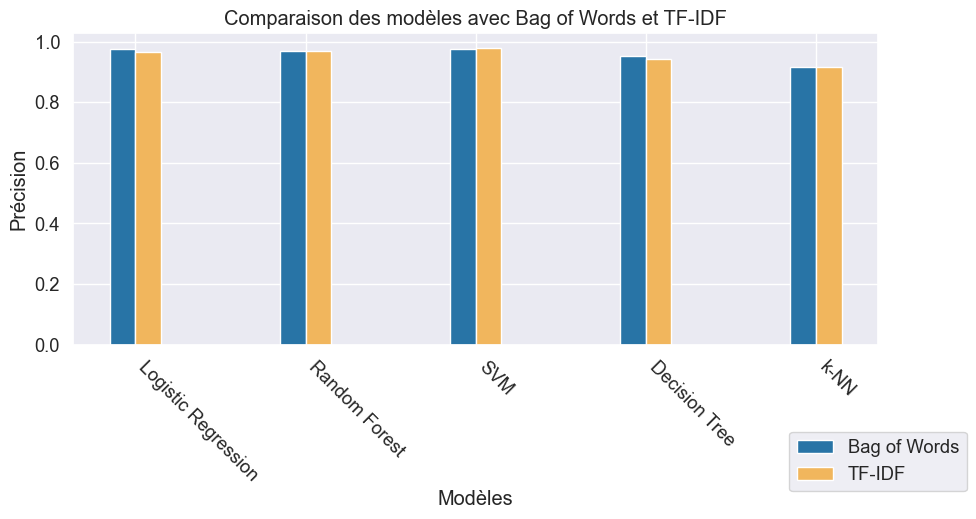

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# Données des performances
labels = list(bow_results.keys())
bow_scores = list(bow_results.values())
tfidf_scores = list(tfidf_results.values())

x = np.arange(len(labels))
width = 0.15

# Création de la figure
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x - width/2, bow_scores, width, label='Bag of Words', color='#2874a6')
ax.bar(x + width/2, tfidf_scores, width, label='TF-IDF', color='#f1b65d')

ax.set_xlabel('Modèles')
ax.set_ylabel('Précision')
ax.set_title('Comparaison des modèles avec Bag of Words et TF-IDF')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=-45, ha='left')

ax.legend(loc='lower center', bbox_to_anchor=(1, -.5), ncol=1)

# Ajuster les espacements
plt.tight_layout()
plt.show()


# 
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600&display=swap');

.project-header {
    text-align: center;
    background: #fdebd0 ;
    font-family: 'Poppins', Arial, sans-serif;
    color: black;
    font-size: 26px;
    font-weight: bold;
    display: flex;
    justify-content: center;
    align-items: center;    
    height: 50px;          
    box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);
}
</style>

<div class="project-header"> Meilleur Modèle avec les meilleurs paramètres</div>



In [57]:
from sklearn.model_selection import train_test_split

X2 = df['transformed_text']  
y2= df['target'] 
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.3, random_state=42)

In [58]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# Fonction d'objectif pour Optuna
def objective(trial):
    # Hyperparamètres à optimiser
    max_features = trial.suggest_int('vectorizer__max_features', 500, 5000)  # Intervalle des max_features
    ngram_range = trial.suggest_categorical('vectorizer__ngram_range', [(1, 1), (1, 2), (1, 3)])
    min_df = trial.suggest_int('vectorizer__min_df', 1, 5)
    n_estimators = trial.suggest_int('classifier__n_estimators', 50, 200)  # Nombre d'arbres pour RandomForest
    max_depth = trial.suggest_int('classifier__max_depth', 5, 30)  # Profondeur maximale des arbres
    
    # Pipeline avec CountVectorizer et RandomForestClassifier
    pipeline = Pipeline([
        ('vectorizer', CountVectorizer(max_features=max_features, ngram_range=ngram_range, min_df=min_df)),
        ('classifier', RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42))
    ])
    
    # Calculer la précision moyenne en validation croisée
    scores = cross_val_score(pipeline, X2_train, y2_train, cv=5, scoring='accuracy', n_jobs=-1)
    return scores.mean()

# Étape Optuna pour optimiser les hyperparamètres
study = optuna.create_study(direction='maximize')  # Maximiser la précision
study.optimize(objective, n_trials=50)  # 50 essais

# Meilleurs hyperparamètres trouvés
print("Meilleurs paramètres :", study.best_params)
print("Meilleure précision :", study.best_value)

# Entraîner le meilleur modèle avec les paramètres optimaux
best_params = study.best_params
vectorizer_params = {k.replace('vectorizer__', ''): v for k, v in best_params.items() if 'vectorizer' in k}
classifier_params = {k.replace('classifier__', ''): v for k, v in best_params.items() if 'classifier' in k}

final_pipeline = Pipeline([
    ('vectorizer', CountVectorizer(**vectorizer_params)),
    ('classifier', RandomForestClassifier(**classifier_params, random_state=42))
])

final_pipeline.fit(X2_train, y2_train)
y2_pred = final_pipeline.predict(X2_test)

from sklearn.metrics import confusion_matrix, classification_report

# print("Rapport de classification :\n", classification_report(y2_test, y2_pred))
# print("Matrice de confusion :\n", confusion_matrix(y2_test, y2_pred))


c:\LogsInst\envs\nlp_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2024-12-12 15:56:37,221] A new study created in memory with name: no-name-eb82daa1-b04a-4276-8012-8a51cfdaca68
c:\LogsInst\envs\nlp_env\lib\site-packages\optuna\distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 1) which is of type tuple.
  warnings.warn(message)
c:\LogsInst\envs\nlp_env\lib\site-packages\optuna\distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 2) which is of type tuple.
  warnings.warn(message)
c:\LogsInst\envs\nlp_env\lib\site-packages\optuna\distributions.py:524: UserWarning: Choices for a cat

Meilleurs paramètres : {'vectorizer__max_features': 750, 'vectorizer__ngram_range': (1, 2), 'vectorizer__min_df': 2, 'classifier__n_estimators': 121, 'classifier__max_depth': 29}
Meilleure précision : 0.9676600719836775


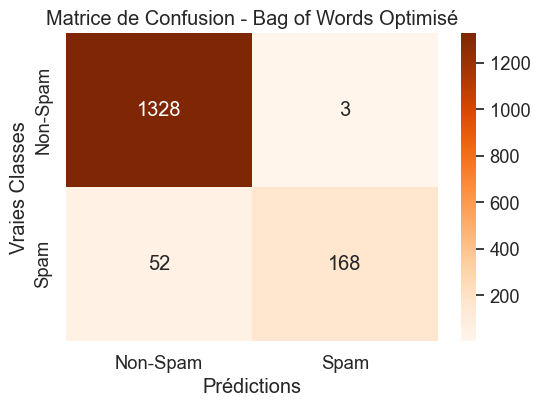

In [59]:
# Calculer la matrice de confusion
conf_matrix_optimized = confusion_matrix(y2_test, y2_pred)

# Affichage de la matrice de confusion
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_optimized, annot=True, fmt="d", cmap="Oranges", xticklabels=['Non-Spam', 'Spam'], yticklabels=['Non-Spam', 'Spam'])
plt.title("Matrice de Confusion - Bag of Words Optimisé")
plt.xlabel("Prédictions")
plt.ylabel("Vraies Classes")
plt.show()

In [ ]:

import optuna
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# Fonction d'objectif pour Optuna
def objective(trial):
    # Hyperparamètres à optimiser
    vectorizer_type = trial.suggest_categorical('vectorizer_type', ['count', 'tfidf'])
    if vectorizer_type == 'count':
        vectorizer = CountVectorizer(
            max_features=trial.suggest_int('vectorizer__max_features', 500, 5000),
            ngram_range=trial.suggest_categorical('vectorizer__ngram_range', [(1, 1), (1, 2), (1, 3)]),
            min_df=trial.suggest_int('vectorizer__min_df', 1, 5)
        )
    else:
        vectorizer = TfidfVectorizer(
            max_features=trial.suggest_int('vectorizer__max_features', 500, 5000),
            ngram_range=trial.suggest_categorical('vectorizer__ngram_range', [(1, 1), (1, 2), (1, 3)]),
            min_df=trial.suggest_int('vectorizer__min_df', 1, 5)
        )

    # Sélection de l'algorithme à tester
    classifier_name = trial.suggest_categorical('classifier', ['RandomForest', 'LogisticRegression', 'SVM', 'GradientBoosting'])

    if classifier_name == 'RandomForest':
        classifier = RandomForestClassifier(
            n_estimators=trial.suggest_int('classifier__n_estimators', 50, 200),
            max_depth=trial.suggest_int('classifier__max_depth', 5, 30),
            random_state=42
        )
    elif classifier_name == 'LogisticRegression':
        classifier = LogisticRegression(
            C=trial.suggest_loguniform('classifier__C', 1e-5, 1e5),
            solver=trial.suggest_categorical('classifier__solver', ['liblinear', 'saga']),
            random_state=42
        )
    elif classifier_name == 'SVM':
        classifier = SVC(
            C=trial.suggest_loguniform('classifier__C', 1e-5, 1e5),
            kernel=trial.suggest_categorical('classifier__kernel', ['linear', 'rbf']),
            random_state=42
        )
    else:
        classifier = GradientBoostingClassifier(
            n_estimators=trial.suggest_int('classifier__n_estimators', 50, 200),
            max_depth=trial.suggest_int('classifier__max_depth', 5, 30),
            learning_rate=trial.suggest_loguniform('classifier__learning_rate', 1e-5, 1e0),
            random_state=42
        )

    # Pipeline
    pipeline = Pipeline([
        ('vectorizer', vectorizer),
        ('classifier', classifier)
    ])

    # Calculer la précision moyenne en validation croisée
    scores = cross_val_score(pipeline, X2_train, y2_train, cv=5, scoring='accuracy', n_jobs=-1)
    return scores.mean()

# Étape Optuna pour optimiser les hyperparamètres
study = optuna.create_study(direction='maximize')  # Maximiser la précision
study.optimize(objective, n_trials=50)  # 50 essais

# Meilleurs hyperparamètres trouvés
print("Meilleurs paramètres :", study.best_params)
print("Meilleure précision :", study.best_value)

# Entraîner le meilleur modèle avec les paramètres optimaux
best_params = study.best_params
vectorizer_params = {k.replace('vectorizer__', ''): v for k, v in best_params.items() if 'vectorizer' in k and k != 'vectorizer_type'}
classifier_params = {k.replace('classifier__', ''): v for k, v in best_params.items() if 'classifier' in k and k != 'classifier'}

if best_params['vectorizer_type'] == 'count':
    vectorizer = CountVectorizer(**vectorizer_params)
else:
    vectorizer = TfidfVectorizer(**vectorizer_params)

if best_params['classifier'] == 'RandomForest':
    classifier = RandomForestClassifier(**classifier_params, random_state=42)
elif best_params['classifier'] == 'LogisticRegression':
    classifier = LogisticRegression(**classifier_params, random_state=42)
elif best_params['classifier'] == 'SVM':
    classifier = SVC(**classifier_params, random_state=42)
else:
    classifier = GradientBoostingClassifier(**classifier_params, random_state=42)

# Final Pipeline
final_pipeline = Pipeline([
    ('vectorizer', vectorizer),
    ('classifier', classifier)
])

# Entraînement final
final_pipeline.fit(X2_train, y2_train)

# Prédictions et évaluation
y2_pred = final_pipeline.predict(X2_test)
from sklearn.metrics import classification_report, confusion_matrix

print("Rapport de classification :\n", classification_report(y2_test, y2_pred))
print("Matrice de confusion :\n", confusion_matrix(y2_test, y2_pred))


[I 2024-12-12 16:06:23,131] A new study created in memory with name: no-name-1646135f-0f83-4847-9afb-0d6c2bdf8155
c:\LogsInst\envs\nlp_env\lib\site-packages\optuna\distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 1) which is of type tuple.
  warnings.warn(message)
c:\LogsInst\envs\nlp_env\lib\site-packages\optuna\distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 2) which is of type tuple.
  warnings.warn(message)
c:\LogsInst\envs\nlp_env\lib\site-packages\optuna\distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 3) which is of type tuple.
  warnings.warn(message)
C:\Users\sirou\AppData\Local\Temp\ipykernel_1876\3676029043.py:162: FutureWarning:

Meilleurs paramètres : {'vectorizer_type': 'count', 'vectorizer__max_features': 2788, 'vectorizer__ngram_range': (1, 3), 'vectorizer__min_df': 2, 'classifier': 'LogisticRegression', 'classifier__C': 38.94866407533139, 'classifier__solver': 'liblinear'}
Meilleure précision : 0.9787166731620092
Rapport de classification :
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      1331
           1       0.97      0.87      0.92       220

    accuracy                           0.98      1551
   macro avg       0.97      0.93      0.95      1551
weighted avg       0.98      0.98      0.98      1551

Matrice de confusion :
 [[1325    6]
 [  29  191]]


# Equilibrage des données 

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Diviser les données
X = df['transformed_text']
y = df['target']

# Diviser les données en train et test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




vectorizer = CountVectorizer(max_features=2788, ngram_range=(1, 7), )
# vectorizer = CountVectorizer(max_features=2788, ngram_range=(1, 3), min_df=5)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Calculer automatiquement les poids de classe
weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.array([0, 1]), y=y_train)
class_weights = {0: weights[0], 1: weights[1]}

print("Poids de la classe 0 :", class_weights[0])
print("Poids de la classe 1 :", class_weights[1])

model = LogisticRegression(C= 36.94866407533139, solver = 'liblinear', class_weight=class_weights)
model.fit(X_train_tfidf, y_train)

# Évaluation du modèle
y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))
print("Matrice de confusion :\n", confusion_matrix(y_test, y_pred))




Poids de la classe 0 : 0.5700303280948442
Poids de la classe 1 : 4.06988188976378
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       889
           1       0.90      0.92      0.91       145

    accuracy                           0.97      1034
   macro avg       0.95      0.95      0.95      1034
weighted avg       0.98      0.97      0.97      1034

Matrice de confusion :
 [[875  14]
 [ 12 133]]


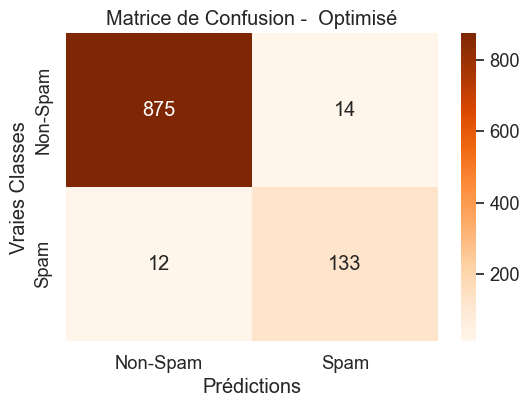

In [160]:
# Calculer la matrice de confusion
conf_matrix_optimized = confusion_matrix(y_test, y_pred)

# Affichage de la matrice de confusion
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_optimized, annot=True, fmt="d", cmap="Oranges", xticklabels=['Non-Spam', 'Spam'], yticklabels=['Non-Spam', 'Spam'])
plt.title("Matrice de Confusion -  Optimisé")
plt.xlabel("Prédictions")
plt.ylabel("Vraies Classes")
plt.show()